In [1]:
from datetime import datetime

from pathlib import Path

import numpy as np
from scipy.stats import lognorm
import pandas as pd

from astropy import stats
import astropy.units as u
from astropy.io import fits
from astropy.visualization import hist

from matplotlib import style
import matplotlib.colors as mcolors
style.use('ggplot')
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2
#%matplotlib widget

In [3]:
rootdir = Path("./data")
# use find to make this csv list
with open(rootdir / "reanalyze_2025_q3.txt") as f:
    csvs = f.readlines()

# loop through the csv files and read them with pandas
frames = []
for csv in csvs:
    frames.append(pd.read_csv(rootdir / csv.rstrip()))

# now concat each frame into one big frame containing all of the data
data = pd.concat(frames)

In [4]:
g = data.groupby('wfs')
g.wfs.describe()

,count,unique,top,freq
wfs,,,,
binospec,10262,1,binospec,10262
f5,138,1,f5,138
mmirs,3117,1,mmirs,3117


In [5]:
# re-calculate the seeing using updated spot FWHM for binospec. filter out any NaN values...
#fixed_list = []
#for wfskey, group in g:
#    wfs = wfs_systems[wfskey]
#    group = g.get_group(wfskey)
#    #group.apply(seeing, axis=1, args=(wfs,))
#    group['fixed_raw_seeing'], group['fixed_seeing'] = seeing(group, wfs)
#    fixed_list.append(group)
#fixed = pd.concat(fixed_list)
#fixed.rename(index=str, columns={"seeing": "orig_seeing", "raw seeing": "orig_raw_seeing"}, inplace=True)
#fixed.rename(index=str, columns={"fixed_seeing": "seeing", "fixed_raw_seeing": "raw seeing"}, inplace=True)
fixed = data[np.isfinite(data['seeing'])]
fixed = fixed[fixed['fwhm'] > 0.]
fixed = fixed[fixed['seeing'] > 0.]
fixed = fixed[fixed['seeing'] < 4.]
#fixed = fixed[fixed['time'] < "2020-12-31"]

In [6]:
fixed.sort_values(by='time')

,time,wfs,file,exptime,airmass,az,el,osst,outt,chamt,...,xcen,ycen,seeing,raw_seeing,vlt_seeing,raw_vlt_seeing,ellipticity,fwhm,wavefront_rms,residual_rms
0,2025-07-01T08:10:59.686000,binospec,wfs_ff_cal_img_2025.07.01T081059.686.fits,60.0,1.1762,350.889160,58.234093,18.0,16.89,17.90,...,296.500769,251.502283,1.790611,1.973740,1.554915,1.713939,0.062179,9.280153,1244.712061,1618.176330
1,2025-07-01T08:12:02.898000,binospec,wfs_ff_cal_img_2025.07.01T081202.898.fits,60.0,1.1767,350.672577,58.197207,17.0,16.82,17.70,...,296.999861,252.000392,1.973009,2.175347,1.697102,1.871145,0.027522,10.019901,967.344914,1556.068017
2,2025-07-01T08:13:06.056000,binospec,wfs_ff_cal_img_2025.07.01T081306.056.fits,60.0,1.1771,350.453849,58.158884,17.0,16.91,17.80,...,296.497387,251.494709,1.784543,1.967955,1.546846,1.705828,0.046076,9.258793,508.023910,1626.419143
3,2025-07-01T08:14:09.246000,binospec,wfs_ff_cal_img_2025.07.01T081409.246.fits,60.0,1.1776,350.234337,58.119455,18.0,16.97,17.80,...,296.998704,251.510351,1.754781,1.935627,1.521932,1.678781,0.062841,9.139307,387.317153,1550.482355
4,2025-07-01T08:15:12.477000,binospec,wfs_ff_cal_img_2025.07.01T081512.477.fits,60.0,1.1782,350.020093,58.079973,18.0,16.88,17.60,...,296.000557,251.995110,1.925882,2.125011,1.686681,1.861077,0.095970,9.836021,359.193865,1751.333915
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30,2025-09-30T10:07:55.649000,f5,f5wfs_20250930-030758.fits,1.0,1.6116,104.771309,38.354097,12.0,11.79,11.83,...,249.003992,254.995990,0.652362,0.868647,0.592056,0.788346,0.835815,5.894916,18836.064494,14861.812848
31,2025-09-30T10:08:57.311000,f5,f5wfs_20250930-030900.fits,1.0,1.5970,105.035260,38.769045,12.0,11.79,11.83,...,250.004168,243.993067,0.692193,0.916664,0.628299,0.832049,0.188468,6.112872,1582.810843,2589.759345
32,2025-09-30T10:09:07.656000,f5,f5wfs_20250930-030930.fits,20.0,1.5934,105.122367,38.871516,12.0,11.86,11.83,...,248.001079,240.995065,0.857414,1.133928,0.757680,1.002030,0.200281,7.095763,1700.666929,1592.852944
33,2025-09-30T10:09:57.526000,f5,f5wfs_20250930-031020.fits,20.0,1.5875,105.268676,39.043017,12.0,11.89,11.83,...,249.998050,243.009034,0.703220,0.927939,0.644436,0.850370,0.232017,6.164033,934.115897,1517.062022


In [7]:
# create a date-time index so we can group and analyze the data by timestamps
fixed = fixed.set_index(pd.DatetimeIndex(fixed['time'], name='ut'))

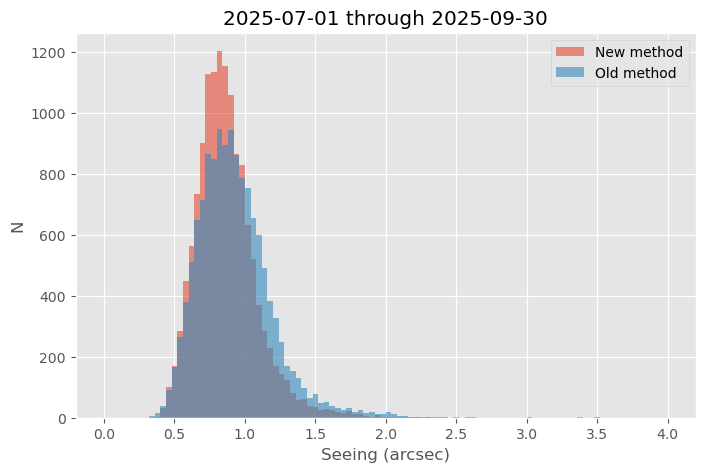

In [8]:
# make raw histogram of the zenith-corrected seeing column
fig = plt.figure(figsize=(8, 5))
plt.hist(fixed['vlt_seeing'], bins=100, range=(0.0, 4.0), alpha=0.6, label="New method")
plt.hist(fixed['seeing'], bins=100, range=(0.0, 4.0), alpha=0.6, label="Old method")
with plt.style.context('ggplot'):
    plt.title("2025-07-01 through 2025-09-30")
    plt.xlabel("Seeing (arcsec)")
    plt.ylabel("N")
plt.legend()
plt.show()

In [9]:
# fit a log-normal distribution to the seeing data
sigma, loc, exp_mu = lognorm.fit(fixed['vlt_seeing'])
print(sigma, loc, exp_mu)
x = np.arange(0.0, 4.0, 0.01)
p = lognorm.pdf(x, sigma, loc=loc, scale=exp_mu)
mu = np.log(exp_mu)
mode = np.exp(mu - sigma**2) + loc
median = np.nanmedian(fixed['vlt_seeing'])
fit_median = exp_mu + loc

0.2706909389033599 0.10052569438878613 0.7391338036428451


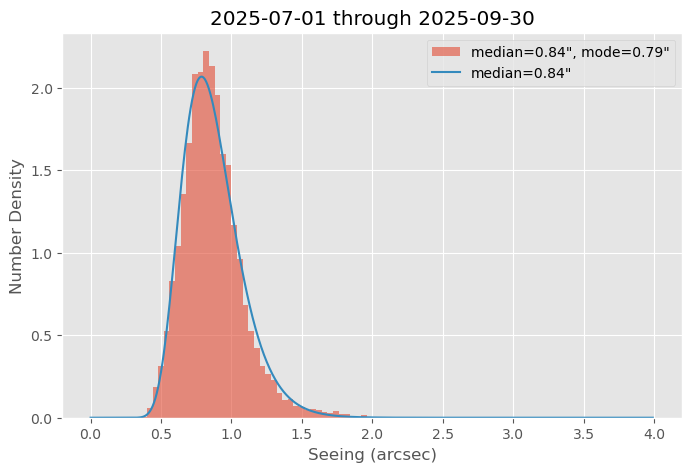

In [10]:
# plot normalized histogram with the fit and the median/mode calculated from the fit.
fig = plt.figure(figsize=(8, 5))
with plt.style.context('ggplot'):
    plt.hist(fixed['vlt_seeing'], density=True, bins=100, range=(0.0, 4.0), label="hist", alpha=0.6)
    logp = plt.plot(x, p, label="logp")
    plt.xlabel("Seeing (arcsec)")
    plt.ylabel("Number Density")
    plt.title("2025-07-01 through 2025-09-30")
    plt.legend(["median=%.2f\", mode=%.2f\"" % (fit_median, mode), "median=%.2f\"" % (
        median
    )])
    plt.savefig("2025_q3.png")
plt.show()

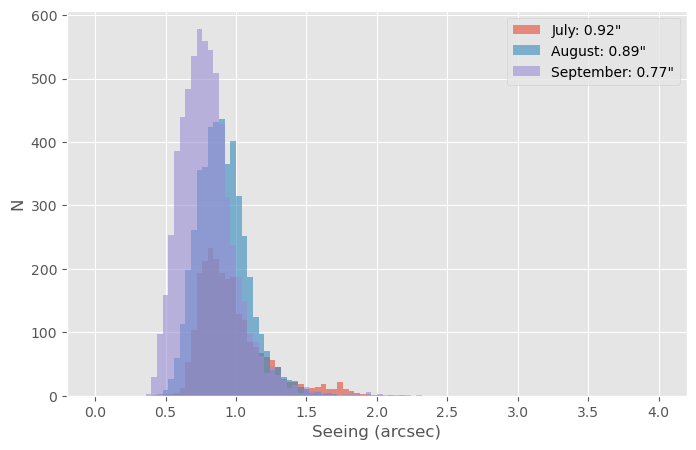

In [11]:
# panda time indexing makes it easy to group by month
fig = plt.figure(figsize=(8, 5))
months = {}
legends = []
months['July'] = fixed.loc['2025-07']
months['August'] = fixed.loc['2025-08']
months['September'] = fixed.loc['2025-09']

for m in months:
    plt.hist(months[m]['vlt_seeing'], bins=100, range=(0.0, 4.0), label=m, alpha=0.6)
    legend = "%s: %.2f\"" % (m, np.median(months[m]['vlt_seeing']))
    legends.append(legend)
plt.legend(legends)
plt.xlabel("Seeing (arcsec)")
plt.ylabel("N")
#plt.title("Data and median seeing values grouped by month")
plt.savefig("2025_q3_monthly.png")
plt.show()

In [12]:
# now use the between_time() method to split the data into first and second halves of the night.
first_half = fixed.between_time(start_time='00:00', end_time='07:00')
second_half = fixed.between_time(start_time='07:00', end_time='14:00')
med_1st = np.median(first_half['vlt_seeing'])
med_2nd = np.median(second_half['vlt_seeing'])

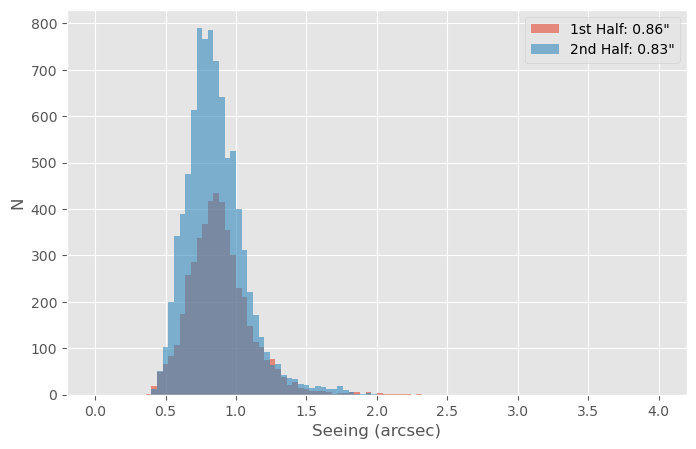

In [13]:
# plot the results and show that the seeing is better later in the night...
fig = plt.figure(figsize=(8, 5))
plt.hist(first_half['vlt_seeing'], bins=100, range=(0.0, 4.0), label="1st", alpha=0.6)
plt.hist(second_half['vlt_seeing'], bins=100, range=(0.0, 4.0), label="2nd", alpha=0.6)
plt.legend(["1st Half: %.2f\"" % med_1st, "2nd Half: %.2f\"" % med_2nd])
plt.xlabel("Seeing (arcsec)")
plt.ylabel("N")
#plt.title("Data and median seeing values grouped by half of the night")
plt.savefig("2025_q3_1st2nd.png")
plt.show()

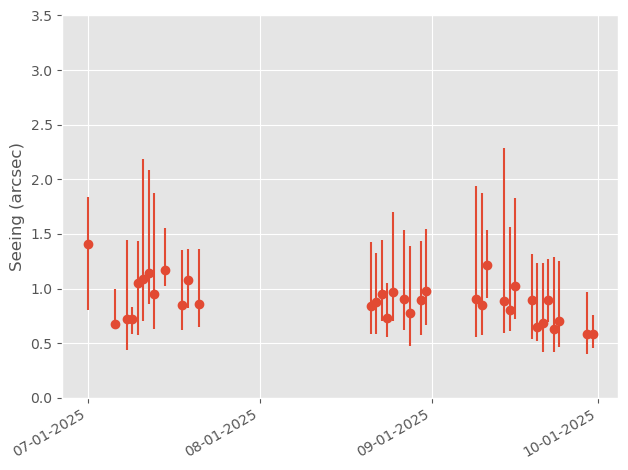

In [14]:
import matplotlib.dates as mdates

# make a new data frame that resamples the WFS data daily into the median, min, and max seeing for each day.
#fixed = fixed["2018-06-30":"2018-10-01"]
fig, ax = plt.subplots()
daily = pd.DataFrame()
daily['seeing'] = fixed.vlt_seeing.resample('D').median()
daily['max'] = fixed.vlt_seeing.resample('D').max()
daily['min'] = fixed.vlt_seeing.resample('D').min()
lowb = daily['seeing'] - daily['min']
upb = daily['max'] - daily['seeing']
plt.errorbar(daily.index, daily['seeing'], yerr=[lowb, upb], fmt='o')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d-%Y"))
ax.set_ylim(0.0, 3.5)
fig.autofmt_xdate()
plt.tight_layout()
plt.ylabel("Seeing (arcsec)")
#plt.title("Nightly median seeing")
plt.savefig("2025_q3_nightly.png")
plt.show()

In [15]:
date_list = list(daily.index.strftime('%Y-%m-%d'))
data = [np.array(fixed.loc[date]['vlt_seeing']) for date in date_list]
ellipticity_data = [np.array(fixed.loc[date]['ellipticity']) for date in date_list]
clean_data = {}
clean_ellipticity = {}
for d, arr in zip(date_list, data):
    if len(arr) > 0:
        clean_data[d] = arr
for d, arr in zip(date_list, ellipticity_data):
    if len(arr) > 0:
        clean_ellipticity[d] = arr
date_labels = [datetime.strptime(d, "%Y-%m-%d").date() for d in clean_data.keys()]

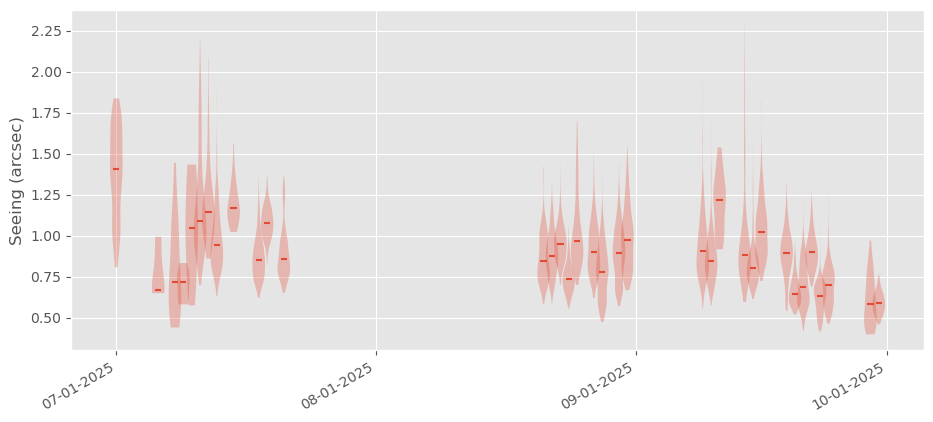

In [16]:
with plt.style.context('ggplot', after_reset=True):
    fig, ax = plt.subplots(figsize=(11,5))
    plt.violinplot(clean_data.values(), mdates.date2num(date_labels), points=50, widths=1.5,
                showextrema=False, showmedians=True, bw_method='silverman')

    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d-%Y"))
    fig.autofmt_xdate()
    plt.ylabel("Seeing (arcsec)")
    plt.savefig("2025_q3_violin.png")
    plt.show()

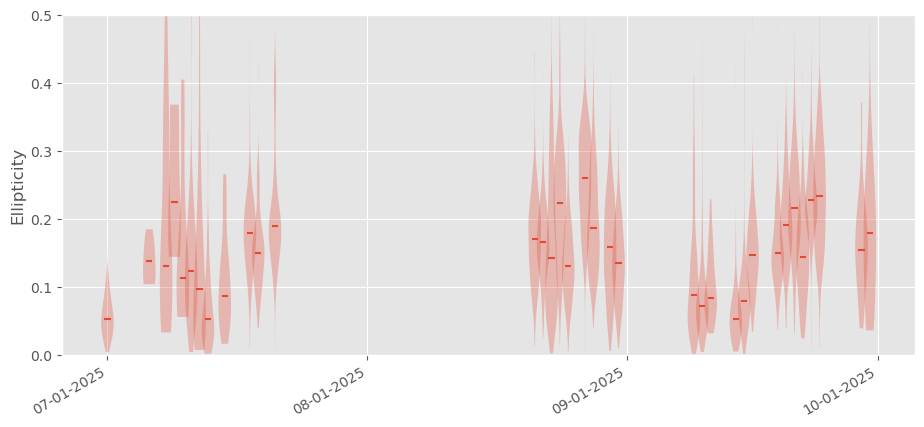

In [17]:
with plt.style.context('ggplot', after_reset=True):
    fig, ax = plt.subplots(figsize=(11,5))
    plt.violinplot(clean_ellipticity.values(), mdates.date2num(date_labels), points=50, widths=1.5,
                showextrema=False, showmedians=True, bw_method='silverman')

    ax.xaxis.set_major_locator(mdates.MonthLocator())

    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d-%Y"))
    fig.autofmt_xdate()
    plt.ylim(0, 0.5)
    plt.ylabel("Ellipticity")
    plt.savefig("2025_q3_ellip_violin.png")
    plt.show()

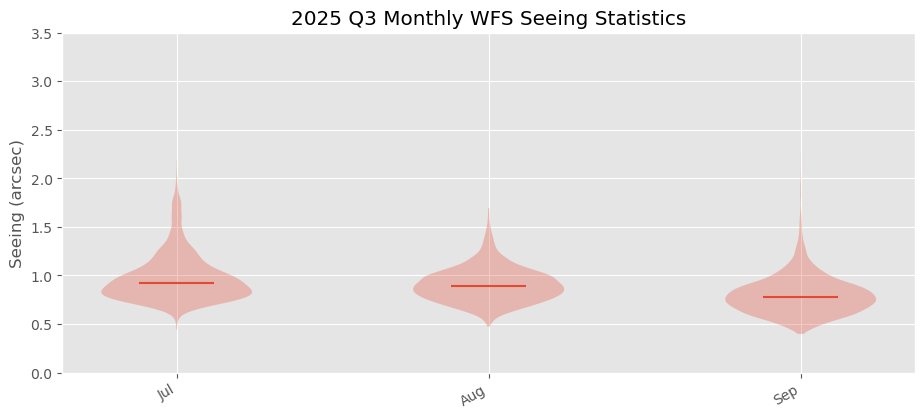

In [18]:
months = sorted(list(set(daily.index.strftime('%Y-%m'))))
mdata = [np.array(fixed.loc[month]['vlt_seeing']) for month in months]
clean_data = {}
for d, arr in zip(months, mdata):
    if len(arr) > 0:
        clean_data[d] = arr
date_labels = [datetime.strptime(d, "%Y-%m").date() for d in clean_data.keys()]

with plt.style.context('ggplot', after_reset=True):
    fig, ax = plt.subplots(figsize=(11,5))
    plt.violinplot(clean_data.values(), mdates.date2num(date_labels), points=100, widths=15,
                showextrema=False, showmedians=True, bw_method='silverman')

    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    ax.set_ylim(0.0, 3.5)
    fig.autofmt_xdate()
    plt.ylabel("Seeing (arcsec)")
    plt.savefig("2025_q3_violin_monthly.png")
    plt.title("2025 Q3 Monthly WFS Seeing Statistics")
    plt.show()

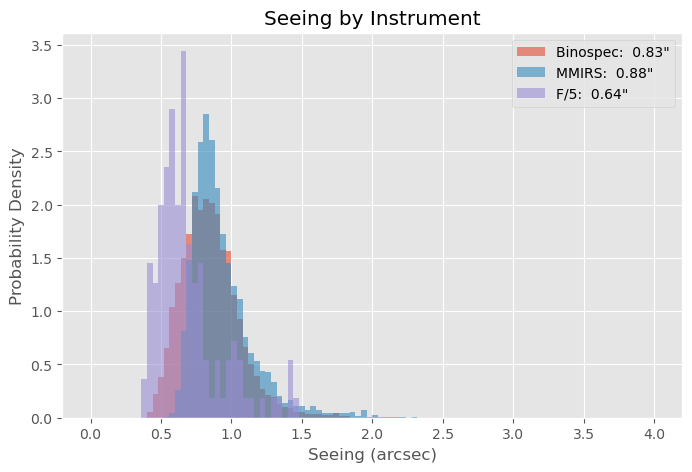

In [19]:
with plt.style.context('ggplot'):
    fig = plt.figure(figsize=(8, 5))
    medb = np.median(fixed['vlt_seeing'][fixed['wfs'] == 'binospec'])
    medm = np.median(fixed['vlt_seeing'][fixed['wfs'] == 'mmirs'])
    med5 = np.median(fixed['vlt_seeing'][fixed['wfs'] == 'f5'])
    plt.hist(fixed['vlt_seeing'][fixed['wfs'] == 'binospec'], density=True, bins=100, range=(0.0, 4.), alpha=0.6, label=f"Binospec: {medb: .2f}\"")
    plt.hist(fixed['vlt_seeing'][fixed['wfs'] == 'mmirs'], density=True, bins=100, range=(0.0, 4.), alpha=0.6, label=f"MMIRS: {medm: .2f}\"")
    plt.hist(fixed['vlt_seeing'][fixed['wfs'] == 'f5'], density=True, bins=100, range=(0.0, 4.), alpha=0.6, label=f"F/5: {med5: .2f}\"")
    plt.legend()
    plt.title("Seeing by Instrument")
    plt.xlabel("Seeing (arcsec)")
    plt.ylabel("Probability Density")
plt.savefig("per_instrument_2025_q3.png")
plt.show()

In [20]:
from minicyclop.io import read_seeing_data

In [21]:
cyclop = read_seeing_data(Path.home() / "MMT/minicyclop/data/MiniCyclop/Data/Seeing_Data.txt")

In [22]:
cyclop

,UT,flux,seeing,r0,isot,epoch_ms
ut,,,,,,
2022-06-08 03:32:32,6/8/2022 3:32:32 AM,2733.7,0.84,135.8,2022-06-08T03:32:32.968,1654659152968
2022-06-08 03:33:27,6/8/2022 3:33:27 AM,2755.7,0.84,134.4,2022-06-08T03:33:27.409,1654659207408
2022-06-08 03:34:23,6/8/2022 3:34:23 AM,2801.6,2.38,47.7,2022-06-08T03:34:23.655,1654659263655
2022-06-08 03:35:16,6/8/2022 3:35:16 AM,2853.2,1.01,112.3,2022-06-08T03:35:16.325,1654659316324
2022-06-08 03:36:00,6/8/2022 3:36:00 AM,2739.0,1.03,110.7,2022-06-08T03:36:00.691,1654659360691
...,...,...,...,...,...,...
2025-10-28 13:12:14,10/28/2025 1:12:14 PM,1806.0,1.28,88.4,2025-10-28T13:12:14.792,1761657134791
2025-10-28 13:13:09,10/28/2025 1:13:09 PM,1772.6,1.08,104.6,2025-10-28T13:13:09.587,1761657189586
2025-10-28 13:14:04,10/28/2025 1:14:04 PM,1909.3,1.19,95.6,2025-10-28T13:14:04.140,1761657244139


In [23]:
cyclop_q3 = cyclop[(cyclop.index >= '2025-07-01') & (cyclop.index < '2025-10-01')]

0.4557067083684997 0.36835859109573044 0.654223058933583


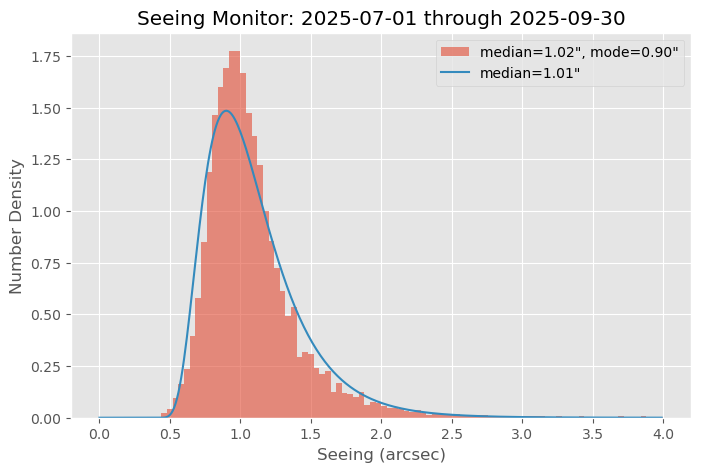

In [24]:
# fit a log-normal distribution to the seeing data
sigma, loc, exp_mu = lognorm.fit(cyclop_q3['seeing'])
print(sigma, loc, exp_mu)
x = np.arange(0.0, 4.0, 0.01)
p = lognorm.pdf(x, sigma, loc=loc, scale=exp_mu)
mu = np.log(exp_mu)
mode = np.exp(mu - sigma**2) + loc
median = np.nanmedian(cyclop_q3['seeing'])
fit_median = exp_mu + loc

# plot normalized histogram with the fit and the median/mode calculated from the fit.
fig = plt.figure(figsize=(8, 5))
with plt.style.context('ggplot'):
    plt.hist(cyclop_q3['seeing'], density=True, bins=100, range=(0.0, 4.0), label="hist", alpha=0.6)
    logp = plt.plot(x, p, label="logp")
    plt.xlabel("Seeing (arcsec)")
    plt.ylabel("Number Density")
    plt.title("Seeing Monitor: 2025-07-01 through 2025-09-30")
    plt.legend(["median=%.2f\", mode=%.2f\"" % (fit_median, mode), "median=%.2f\"" % (
        median
    )])
    plt.savefig("2025_q3_cyclop_hist.png")
plt.show()

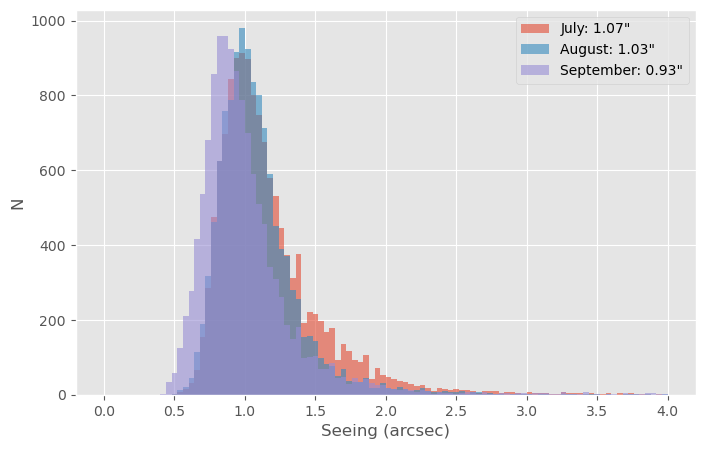

In [25]:
# panda time indexing makes it easy to group by month
fig = plt.figure(figsize=(8, 5))
cyc_months = {}
legends = []
cyc_months['July'] = cyclop_q3.loc['2025-07']
cyc_months['August'] = cyclop_q3.loc['2025-08']
cyc_months['September'] = cyclop_q3.loc['2025-09']

for m in cyc_months.keys():
    plt.hist(cyc_months[m]['seeing'], bins=100, range=(0.0, 4.0), label=m, alpha=0.6)
    legend = "%s: %.2f\"" % (m, np.median(cyc_months[m]['seeing']))
    legends.append(legend)
plt.legend(legends)
plt.xlabel("Seeing (arcsec)")
plt.ylabel("N")
#plt.title("Data and median seeing values grouped by month")
plt.savefig("2025_q3_cyclop_monthly.png")
plt.show()

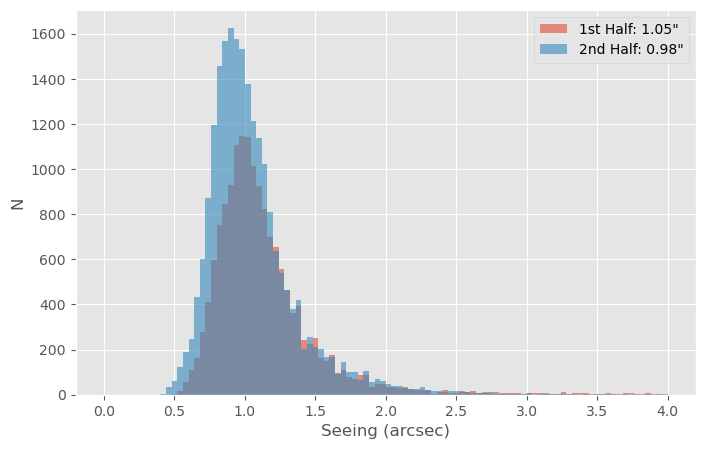

In [26]:
# now use the between_time() method to split the data into first and second halves of the night.
first_half = cyclop_q3.between_time(start_time='00:00', end_time='07:00')
second_half = cyclop_q3.between_time(start_time='07:00', end_time='14:00')
med_1st = np.median(first_half['seeing'])
med_2nd = np.median(second_half['seeing'])

# plot the results and show that the seeing is better later in the night...
fig = plt.figure(figsize=(8, 5))
plt.hist(first_half['seeing'], bins=100, range=(0.0, 4.0), label="1st", alpha=0.6)
plt.hist(second_half['seeing'], bins=100, range=(0.0, 4.0), label="2nd", alpha=0.6)
plt.legend(["1st Half: %.2f\"" % med_1st, "2nd Half: %.2f\"" % med_2nd])
plt.xlabel("Seeing (arcsec)")
plt.ylabel("N")
#plt.title("Data and median seeing values grouped by half of the night")
plt.savefig("2025_q3_cyclop_1st2nd.png")
plt.show()

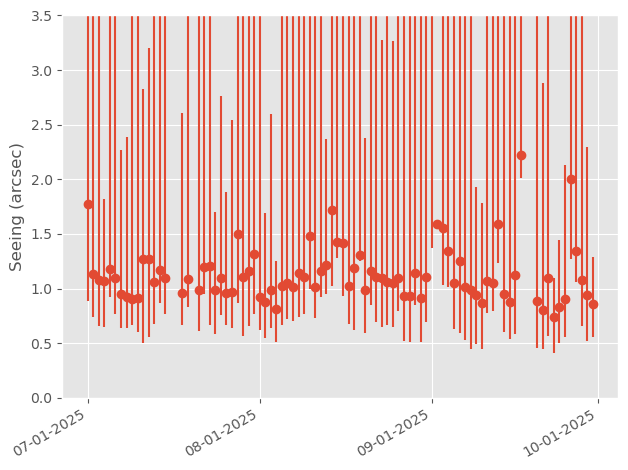

In [27]:
# make a new data frame that resamples the WFS data daily into the median, min, and max seeing for each day.
#fixed = fixed["2018-06-30":"2018-10-01"]
fig, ax = plt.subplots()
daily = pd.DataFrame()
daily['seeing'] = cyclop_q3.seeing.resample('D').median()
daily['max'] = cyclop_q3.seeing.resample('D').max()
daily['min'] = cyclop_q3.seeing.resample('D').min()
lowb = daily['seeing'] - daily['min']
upb = daily['max'] - daily['seeing']
plt.errorbar(daily.index, daily['seeing'], yerr=[lowb, upb], fmt='o')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d-%Y"))
ax.set_ylim(0.0, 3.5)
fig.autofmt_xdate()
plt.tight_layout()
plt.ylabel("Seeing (arcsec)")
#plt.title("Nightly median seeing")
plt.savefig("2025_q3_cyclop_plot_monthly.png")
plt.show()

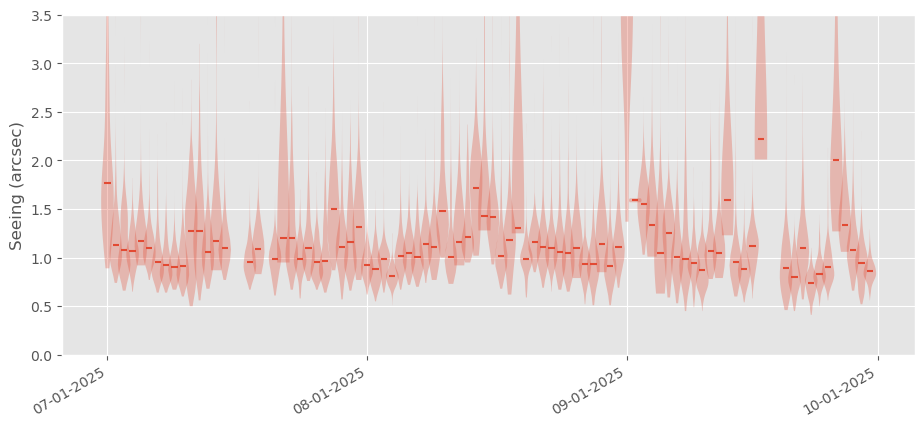

In [28]:
date_list = list(daily.index.strftime('%Y-%m-%d'))
data = [np.array(cyclop_q3.loc[date]['seeing']) for date in date_list]

clean_data = {}
for d, arr in zip(date_list, data):
    if len(arr) > 0:
        clean_data[d] = arr
date_labels = [datetime.strptime(d, "%Y-%m-%d").date() for d in clean_data.keys()]

with plt.style.context('ggplot', after_reset=True):
    fig, ax = plt.subplots(figsize=(11,5))
    plt.violinplot(clean_data.values(), mdates.date2num(date_labels), points=50, widths=1.5,
                showextrema=False, showmedians=True, bw_method='silverman')

    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d-%Y"))
    ax.set_ylim(0.0, 3.5)
    fig.autofmt_xdate()
    plt.ylabel("Seeing (arcsec)")
    plt.savefig("2025_q3_cyclop_violin.png")
    plt.show()

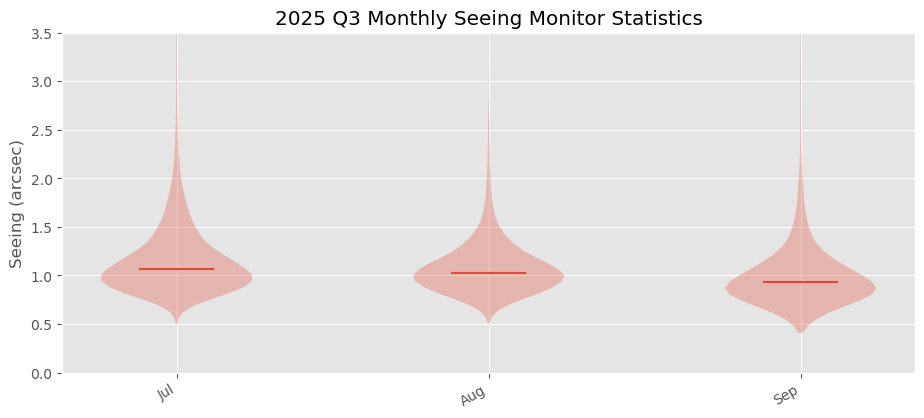

In [29]:
months = sorted(list(set(daily.index.strftime('%Y-%m'))))
mdata = [np.array(cyclop_q3.loc[month]['seeing']) for month in months]
clean_data = {}
for d, arr in zip(months, mdata):
    if len(arr) > 0:
        clean_data[d] = arr
date_labels = [datetime.strptime(d, "%Y-%m").date() for d in clean_data.keys()]

with plt.style.context('ggplot', after_reset=True):
    fig, ax = plt.subplots(figsize=(11,5))
    plt.violinplot(clean_data.values(), mdates.date2num(date_labels), points=100, widths=15,
                showextrema=False, showmedians=True, bw_method='silverman')

    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    ax.set_ylim(0.0, 3.5)
    fig.autofmt_xdate()
    plt.ylabel("Seeing (arcsec)")
    plt.savefig("2025_q3_cyclop_violin_monthly.png")
    plt.title("2025 Q3 Monthly Seeing Monitor Statistics")
    plt.show()

In [30]:
bino = fixed[fixed['wfs'] == 'binospec']
mmirs = fixed[fixed['wfs'] == 'mmirs']
f5 = fixed[fixed['wfs'] == 'f5']

In [32]:
bino_dates = sorted(list(set(bino.index.strftime('%Y-%m-%d'))))
mmirs_dates = sorted(list(set(mmirs.index.strftime('%Y-%m-%d'))))
f5_dates = sorted(list(set(f5.index.strftime('%Y-%m-%d'))))
bino_dates, mmirs_dates, f5_dates

(['2025-07-01',
  '2025-07-18',
  '2025-07-19',
  '2025-07-21',
  '2025-08-21',
  '2025-08-22',
  '2025-08-23',
  '2025-08-24',
  '2025-08-25',
  '2025-08-27',
  '2025-08-28',
  '2025-08-30',
  '2025-08-31',
  '2025-09-16',
  '2025-09-19',
  '2025-09-20',
  '2025-09-21',
  '2025-09-22',
  '2025-09-23',
  '2025-09-24'],
 ['2025-07-11',
  '2025-07-12',
  '2025-07-13',
  '2025-07-15',
  '2025-09-09',
  '2025-09-10',
  '2025-09-11',
  '2025-09-14',
  '2025-09-15'],
 ['2025-07-06',
  '2025-07-08',
  '2025-07-09',
  '2025-07-10',
  '2025-09-29',
  '2025-09-30'])

In [33]:
cyc_bino = np.hstack([np.array(cyclop_q3.loc[date]['seeing']) for date in bino_dates])
cyc_mmirs = np.hstack([np.array(cyclop_q3.loc[date]['seeing']) for date in mmirs_dates])
cyc_f5 = np.hstack([np.array(cyclop_q3.loc[date]['seeing']) for date in f5_dates])

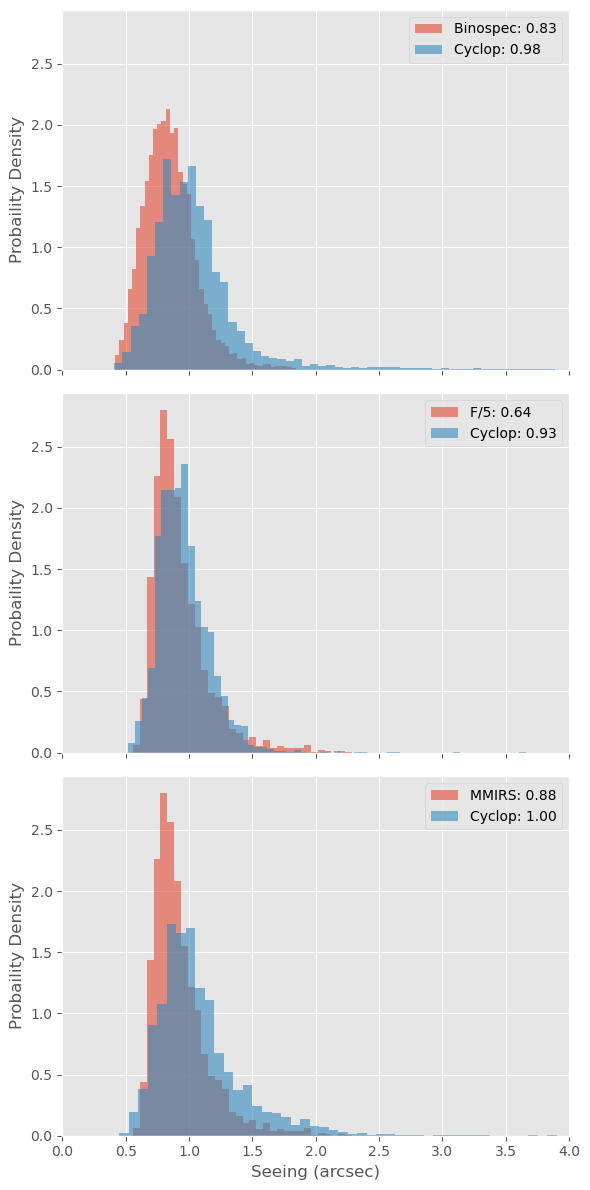

In [36]:
with plt.style.context('ggplot', after_reset=True):
    fig, ax = plt.subplots(3, 1, figsize=(6, 12), sharex=True, sharey=True)
    ax = ax.flat
    fig.subplots_adjust(hspace=0)

    hist(bino['vlt_seeing'], bins='scott', ax=ax[0], histtype='stepfilled', alpha=0.6, density=True)
    hist(cyc_bino, bins='scott', ax=ax[0], histtype='stepfilled', alpha=0.6, density=True)
    ax[0].legend([f"Binospec: {np.median(bino['vlt_seeing']):.2f}", f"Cyclop: {np.median(cyc_bino):.2f}"])
    ax[0].set_ylabel("Probaility Density")
    ax[0].set_xlim(0, 4)

    hist(mmirs['vlt_seeing'], bins='scott', ax=ax[1], histtype='stepfilled', alpha=0.6, density=True)
    hist(cyc_f5, bins='scott', ax=ax[1], histtype='stepfilled', alpha=0.6, density=True)
    ax[1].legend([f"F/5: {np.median(f5['vlt_seeing']):.2f}", f"Cyclop: {np.median(cyc_f5):.2f}"])
    ax[1].set_xlim(0, 4)
    ax[1].set_ylabel("Probaility Density")

    hist(mmirs['vlt_seeing'], bins='scott', ax=ax[2], histtype='stepfilled', alpha=0.6, density=True)
    hist(cyc_mmirs, bins='scott', ax=ax[2], histtype='stepfilled', alpha=0.6, density=True)
    ax[2].legend([f"MMIRS: {np.median(mmirs['vlt_seeing']):.2f}", f"Cyclop: {np.median(cyc_mmirs):.2f}"])
    ax[2].set_xlim(0, 4)
    ax[2].set_xlabel("Seeing (arcsec)")
    ax[2].set_ylabel("Probaility Density")

    plt.tight_layout()
    plt.savefig("2025_q3_cyclop_vs_inst.png")
    plt.show()

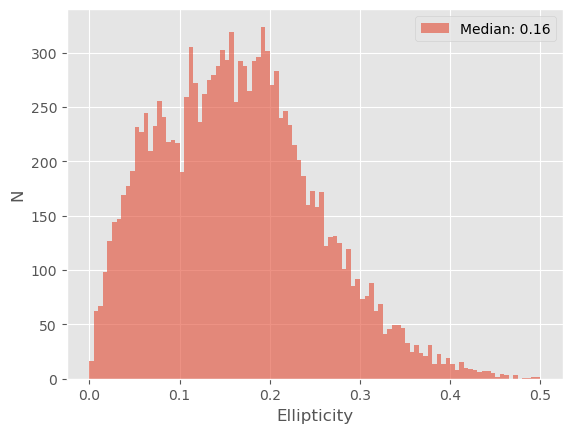

In [37]:
plt.hist(fixed['ellipticity'], bins=100, range=(0.0, 0.5), alpha=0.6, label=f"Median: {np.median(fixed['ellipticity']):.2f}")
plt.xlabel("Ellipticity")
plt.ylabel("N")
plt.legend()
plt.savefig("ellipticity_2025_q3.png")
plt.show()

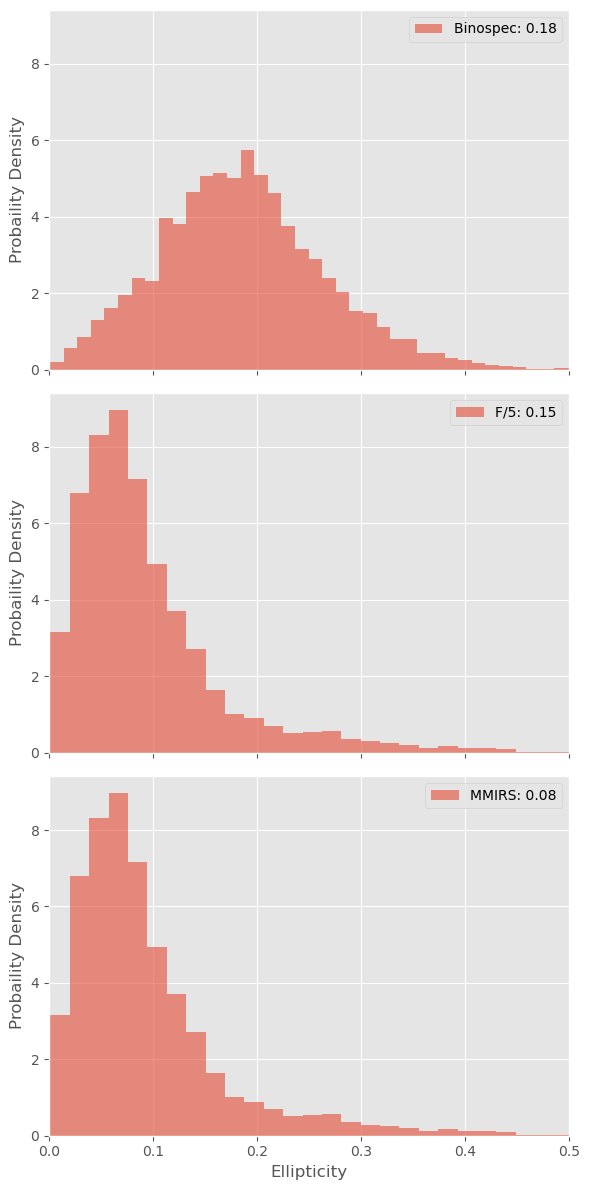

In [38]:
with plt.style.context('ggplot', after_reset=True):
    fig, ax = plt.subplots(3, 1, figsize=(6, 12), sharex=True, sharey=True)
    ax = ax.flat
    fig.subplots_adjust(hspace=0)

    hist(bino['ellipticity'], bins='scott', ax=ax[0], histtype='stepfilled', alpha=0.6, density=True)
    ax[0].legend([f"Binospec: {np.median(bino['ellipticity']):.2f}"])
    ax[0].set_ylabel("Probaility Density")
    ax[0].set_xlim(0, .5)

    hist(mmirs['ellipticity'], bins='scott', ax=ax[1], histtype='stepfilled', alpha=0.6, density=True)
    ax[1].legend([f"F/5: {np.median(f5['ellipticity']):.2f}"])
    ax[1].set_xlim(0, .5)
    ax[1].set_ylabel("Probaility Density")

    hist(mmirs['ellipticity'], bins='scott', ax=ax[2], histtype='stepfilled', alpha=0.6, density=True)
    ax[2].legend([f"MMIRS: {np.median(mmirs['ellipticity']):.2f}"])
    ax[2].set_xlim(0, .5)
    ax[2].set_xlabel("Ellipticity")
    ax[2].set_ylabel("Probaility Density")

    plt.tight_layout()
    plt.savefig("2025_q3_ellip_vs_inst.png")
    plt.show()

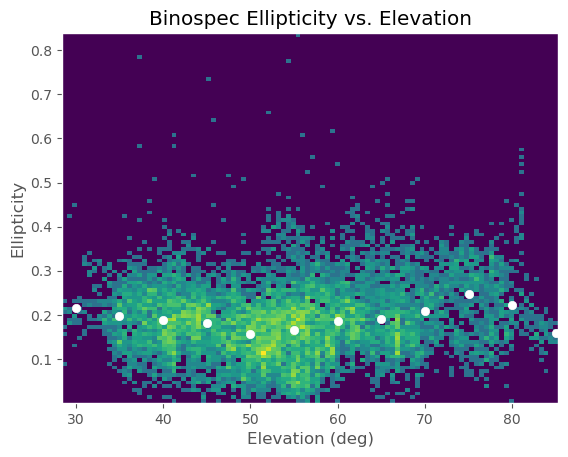

In [39]:
els = [30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85]
e_meds = []
for el in els:
    slice = bino[(bino['el'] >= el-2.5) & (bino['el'] <= el+2.5)]
    e_meds.append(np.median(slice['ellipticity']))

with plt.style.context('ggplot', after_reset=True):
    plt.hist2d(bino['el'], bino['ellipticity'], bins=100, cmap='viridis', norm=mcolors.PowerNorm(0.3))
    plt.scatter(els, e_meds, color='w')
    plt.xlabel("Elevation (deg)")
    plt.ylabel("Ellipticity")
    plt.title("Binospec Ellipticity vs. Elevation")
    plt.savefig("2025q3_bino_ellip_vs_el.png")
    plt.show()